Generate Figure 17 from Ugliotti et ali., Data-driven equivariant LES model of incompressible fluid turbulence.

This notebook does:

1. Load DNS of `w(x,y)` from a NetCDF file (variable name: `w`).
2. Calculculate the viscous dissipation to SGS dissipation for a range of deltas. 
3. Save that, and then put back all the saved files together in one plot.

In [1]:
# ----------------------------
# Imports & configuration
# ----------------------------
from __future__ import annotations

from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

import jax_cfd.base as cfd
import jax_cfd.base.grids as grids
import jax_cfd.spectral as spectral

jax.config.update("jax_enable_x64", True)

In [2]:
# ----------------------------
# User knobs
# ----------------------------
# Input: NetCDF containing vorticity variable `w` on a periodic 2pi box
INP = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/DNS.nc")

# Output: Where to save
OUT_DIR = Path("/storage/home/hcoda1/4/mugliotti3/scratch/temporary/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Make output directory
OUT_PATH = OUT_DIR / "Fig17_1.txt"
TXT_PATH = OUT_PATH  # keep name if you reference it elsewhere
OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
TXT_PATH.parent.mkdir(parents=True, exist_ok=True)

Lengthscale = 1    #Here you should put your lengthscale from the Lengthscale script
n_deltas = 100     #amount of deltas for smooth plot
xmin = 0.01        #xmin*Lengthscale = minimum filter scale
xmax = 3.0         #xmax*Lengthscale = maximum filter scale
make_plot = True   #If you want to plot it
also_plot_abs_loglog = True #If you want to plot in logscale (recommended)

stride_t = 1
stride_delta = 1

Loaded w0 with shape (Nt, Nx, Ny) = (10, 512, 512)


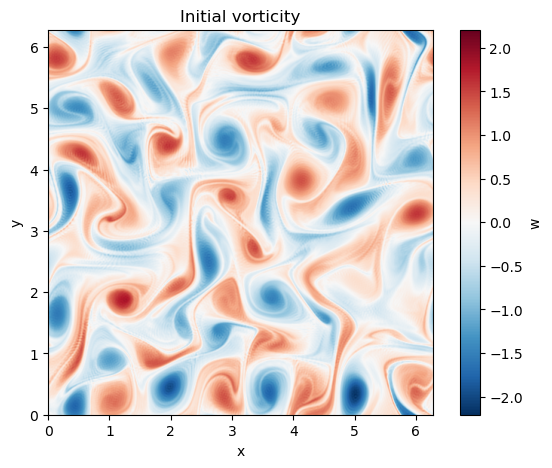

In [3]:
# ----------------------------
# Load initial vorticity
# ----------------------------
ds = xr.open_dataset(INP)
nu = float(ds.attrs["nu"])  
if "w" not in ds:
    raise KeyError(f"Expected variable 'w' in {INP}, found: {list(ds.data_vars)}")

w0 = jnp.asarray(ds["w"].values)
if w0.ndim != 3:
    raise ValueError(f"Expected 2D vorticity field, got shape {w0.shape}")

Nt, Nx, Ny = w0.shape
print(f"Loaded w0 with shape (Nt, Nx, Ny) = {w0.shape}")

# Quick look
plt.figure(figsize=(7, 5))
vmax = np.max(np.abs(w0[0,:,:]))
plt.imshow(w0[0,:,:], origin="lower", cmap="RdBu_r",extent=[0, 2*np.pi, 0, 2*np.pi], vmin=-vmax, vmax=vmax)
plt.colorbar(label="w")
plt.title("Initial vorticity")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

In [4]:
# ----------------------------
# Convert omega to U,V
# ----------------------------
Nt, Nx, Ny = w0.shape   # w0 = (time, x, y)

grid = grids.Grid((Nx, Ny), domain=((0.0, 2*jnp.pi), (0.0, 2*jnp.pi)))
w_to_v_dns = spectral.utils.vorticity_to_velocity(grid)

# FFT per snapshot
w_hat = jnp.fft.rfft2(jnp.asarray(w0, dtype=jnp.float64), axes=(1, 2))
# shape: (Nt, Nx, Ny//2+1)

# ---- vectorize the operator over time ----
u_hat, v_hat = jax.vmap(w_to_v_dns)(w_hat)
# shapes: (Nt, Nx, Ny//2+1)

U = jnp.fft.irfft2(u_hat, axes=(1, 2))
V = jnp.fft.irfft2(v_hat, axes=(1, 2))
# shapes: (Nt, Nx, Ny)

# ---- transpose to what your ratios code expects ----
U = jnp.transpose(U, (1, 2, 0))   # (Nx, Ny, Nt)
V = jnp.transpose(V, (1, 2, 0))

[diag] Nx,Ny,Nt = (512, 512, 10)
[diag] nu = 1e-06 L = 1.0 Δ range = (0.01, 3.0)
[diag] Pi_mean min/max = 3.611683318793872e-10 8.068698653060072e-05
[diag] eps_mean min/max = 2.6350431463293494e-10 3.933766733787426e-07
[diag] R min/max = 0.0009181234077183187 6542.3492110593725
[diag] count R<=0: 0 out of 100
[diag] count nonfinite: 0


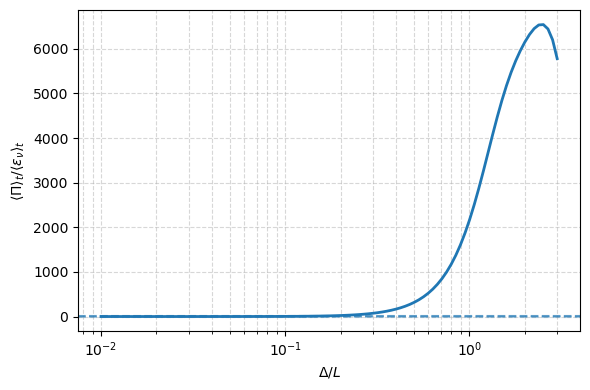

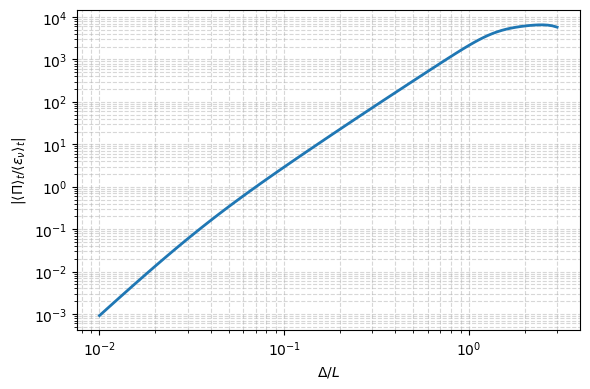

Saved NetCDF: /storage/home/hcoda1/4/mugliotti3/scratch/temporary/Fig17_1.txt
Saved TXT: /storage/home/hcoda1/4/mugliotti3/scratch/temporary/Fig17_1.txt


In [5]:
# ----------------------------
# Calculate quantities for the figure and save it
# ----------------------------
def rfft_mesh_2d(Nx, Ny, Lx=2*jnp.pi, Ly=2*jnp.pi):
    kx = jnp.fft.fftfreq(Nx, d=Lx/Nx) * 2*jnp.pi          # (Nx,)
    ky = jnp.fft.rfftfreq(Ny, d=Ly/Ny) * 2*jnp.pi         # (Ny//2+1,)
    return kx[:, None], ky[None, :]

def irfft2_xy(Ahat):
    return jnp.fft.irfft2(Ahat, axes=(0, 1))

def gaussian_filter_hat(kx, ky, Delta):
    kk = jnp.sqrt(kx**2 + ky**2)
    return jnp.exp(-(kk * Delta)**2 / 24.0)

def filtered_strain_from_hat(Uf_hat, Vf_hat, kx, ky):
    i = 1j
    ux_x = irfft2_xy(i * kx * Uf_hat)
    ux_y = irfft2_xy(i * ky * Uf_hat)
    uy_x = irfft2_xy(i * kx * Vf_hat)
    uy_y = irfft2_xy(i * ky * Vf_hat)

    Sxx = ux_x
    Syy = uy_y
    Sxy = 0.5 * (ux_y + uy_x)
    return Sxx, Sxy, Syy

def eps_nu_from_S(Sxx, Sxy, Syy, nu):
    S2 = Sxx*Sxx + 2.0*Sxy*Sxy + Syy*Syy
    return 2.0 * nu * jnp.mean(S2)

def deltas_geom(n, L, xmin=0.01, xmax=1.0):
    return np.geomspace(xmin*L, xmax*L, num=n).astype(np.float64)

def precompute_spectral_fields(U, V):
    U = jnp.asarray(U)
    V = jnp.asarray(V)
    U_hat  = jnp.fft.rfft2(U, axes=(0, 1))
    V_hat  = jnp.fft.rfft2(V, axes=(0, 1))
    UU_hat = jnp.fft.rfft2(U*U, axes=(0, 1))
    VV_hat = jnp.fft.rfft2(V*V, axes=(0, 1))
    UV_hat = jnp.fft.rfft2(U*V, axes=(0, 1))
    return dict(U_hat=U_hat, V_hat=V_hat, UU_hat=UU_hat, VV_hat=VV_hat, UV_hat=UV_hat)

@jax.jit
def _pi_eps_single_t(U_hat_t, V_hat_t, UU_hat_t, VV_hat_t, UV_hat_t, kx, ky, G, nu):
    Uf_hat = U_hat_t * G
    Vf_hat = V_hat_t * G

    Uf = irfft2_xy(Uf_hat)
    Vf = irfft2_xy(Vf_hat)

    UUf = irfft2_xy(UU_hat_t * G)
    VVf = irfft2_xy(VV_hat_t * G)
    UVf = irfft2_xy(UV_hat_t * G)

    txx = UUf - Uf*Uf
    tyy = VVf - Vf*Vf
    txy = UVf - Uf*Vf

    Sxx, Sxy, Syy = filtered_strain_from_hat(Uf_hat, Vf_hat, kx, ky)

    # keep your abs convention
    Pi = jnp.abs(jnp.mean(txx*Sxx + 2.0*txy*Sxy + tyy*Syy))
    eps = eps_nu_from_S(Sxx, Sxy, Syy, nu)
    return Pi, eps

def ratios_vs_delta_over_L_fast(U, V, nu, L, n_deltas=100, xmin=0.01, xmax=1.0,
                               Lx=2*np.pi, Ly=2*np.pi, stride_t=1, stride_delta=1,
                               make_plot=True, also_plot_abs_loglog=False):
    U = jnp.asarray(U)
    V = jnp.asarray(V)
    Nx, Ny, Nt = U.shape

    spec = precompute_spectral_fields(U, V)
    U_hat, V_hat = spec["U_hat"], spec["V_hat"]
    UU_hat, VV_hat, UV_hat = spec["UU_hat"], spec["VV_hat"], spec["UV_hat"]

    kx, ky = rfft_mesh_2d(Nx, Ny, Lx, Ly)
    Deltas = deltas_geom(n_deltas, L=L, xmin=xmin, xmax=xmax)[::stride_delta]
    X = (Deltas / L).astype(np.float64)
    t_idx = np.arange(0, Nt, stride_t)

    ratios, Pi_means, eps_means = [], [], []
    for Delta in Deltas:
        G = gaussian_filter_hat(kx, ky, float(Delta))
        Pis, Eps = [], []
        for t in t_idx:
            Pi, eps = _pi_eps_single_t(U_hat[:, :, t], V_hat[:, :, t],
                                       UU_hat[:, :, t], VV_hat[:, :, t], UV_hat[:, :, t],
                                       kx, ky, G, float(nu))
            Pis.append(Pi); Eps.append(eps)

        Pi_mean = jnp.mean(jnp.stack(Pis))
        eps_mean = jnp.mean(jnp.stack(Eps))
        Pi_means.append(Pi_mean)
        eps_means.append(eps_mean)
        ratios.append(Pi_mean / (eps_mean + 1e-30))

    R = np.array(jnp.asarray(ratios), dtype=np.float64)
    Pi_m = np.array(jnp.asarray(Pi_means), dtype=np.float64)
    eps_m = np.array(jnp.asarray(eps_means), dtype=np.float64)

    print("[diag] Nx,Ny,Nt =", (Nx, Ny, Nt))
    print("[diag] nu =", float(nu), "L =", float(L), "Δ range =", (float(Deltas.min()), float(Deltas.max())))
    print("[diag] Pi_mean min/max =", np.nanmin(Pi_m), np.nanmax(Pi_m))
    print("[diag] eps_mean min/max =", np.nanmin(eps_m), np.nanmax(eps_m))
    print("[diag] R min/max =", np.nanmin(R), np.nanmax(R))
    print("[diag] count R<=0:", int(np.sum(R <= 0)), "out of", R.size)
    print("[diag] count nonfinite:", int(np.sum(~np.isfinite(R))))

    if make_plot:
        plt.figure(figsize=(6, 4))
        plt.semilogx(X, R, lw=2)
        plt.axhline(1.0, ls="--", alpha=0.7)
        plt.axhline(0.0, ls="--", alpha=0.4)
        plt.xlabel(r"$\Delta / L$")
        plt.ylabel(r"$\langle \Pi \rangle_t / \langle \varepsilon_\nu \rangle_t$")
        plt.grid(True, which="both", ls="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    if also_plot_abs_loglog:
        plt.figure(figsize=(6, 4))
        plt.plot(X, np.abs(R), lw=2)
        plt.xscale("log")
        plt.yscale("log")
        plt.xlabel(r"$\Delta / L$")
        plt.ylabel(r"$|\langle \Pi \rangle_t / \langle \varepsilon_\nu \rangle_t|$")
        plt.grid(True, which="both", ls="--", alpha=0.5)
        plt.tight_layout()
        plt.show()

    return X, R, Pi_m, eps_m

def w_to_uv_via_jaxcfd(w_in, domain=((0.0, 2*jnp.pi), (0.0, 2*jnp.pi))):
    w_np = np.asarray(w_in)
    if w_np.ndim == 2:
        w_np = w_np[None, :, :]
    if w_np.ndim != 3:
        raise ValueError(f"Expected w as (Ny,Nx) or (Nt,Ny,Nx), got {w_np.shape}")

    Nt, Ny, Nx = w_np.shape
    w = jnp.asarray(w_np, dtype=jnp.float64)
    w_xyt = jnp.transpose(w, (2, 1, 0))  # (Nx,Ny,Nt)

    grid = grids.Grid((Nx, Ny), domain=domain)
    w_to_v_dns = spectral.utils.vorticity_to_velocity(grid)

    w_hat = jnp.fft.rfft2(w_xyt, axes=(0, 1))
    u_hat, v_hat = w_to_v_dns(w_hat)

    U = jnp.fft.irfft2(u_hat, axes=(0, 1))
    V = jnp.fft.irfft2(v_hat, axes=(0, 1))
    return U, V, grid


# compute ratios
X, R, Pi_m, eps_m = ratios_vs_delta_over_L_fast(
    U, V, nu,
    L=Lengthscale,
    n_deltas=n_deltas,
    xmin=xmin,
    xmax=xmax,
    stride_t=stride_t,
    stride_delta=stride_delta,
    make_plot=make_plot,
    also_plot_abs_loglog=also_plot_abs_loglog,
)

# ----------------------------
# SAVE outputs to NetCDF (safe relative path)
# ----------------------------
ds_out = xr.Dataset(
    data_vars=dict(
        ratio=(("delta_index",), R.astype(np.float32)),
        Pi_mean=(("delta_index",), Pi_m.astype(np.float32)),
        eps_mean=(("delta_index",), eps_m.astype(np.float32)),
        Delta_over_L=(("delta_index",), X.astype(np.float32)),
    ),
    coords=dict(
        delta_index=("delta_index", np.arange(len(X), dtype=np.int32)),
    ),
    attrs=dict(
        inp=str(INP),
        nu=float(nu),
        L=float(Lengthscale),
        n_deltas=int(n_deltas),
        xmin=float(xmin),
        xmax=float(xmax),
        stride_t=int(stride_t),
        stride_delta=int(stride_delta),
        filter="Gaussian exp(-(kΔ)^2/24)",
        Pi_convention="abs(mean(tau_ij S_ij))",
    ),
)

encoding = {
    "ratio": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "Pi_mean": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "eps_mean": {"zlib": True, "complevel": 4, "dtype": "float32"},
    "Delta_over_L": {"zlib": True, "complevel": 4, "dtype": "float32"},
}

ds_out.to_netcdf(OUT_PATH, encoding=encoding)
print("Saved NetCDF:", OUT_PATH)

# Also save txt (optional)
header = "Delta_over_L  ratio_Pi_over_eps  Pi_mean  eps_mean"
np.savetxt(TXT_PATH, np.column_stack([X, R, Pi_m, eps_m]), header=header)
print("Saved TXT:", TXT_PATH)